# GiBUU Propagation Model Training

This notebook trains the `GiBUUPropagationModel` for predicting particle feature changes during propagation.

**Workflow:**
1. Load processed NPZ data from `GiBUU_dataprep.ipynb`
2. Prepare data for training (call `prepare_propagation_data`)
3. Configure model and training parameters
4. Train model with PyTorch Lightning
5. Test trained model

**Model Architecture:**
- Zero-inflated architecture for E/p predictions (handles sparse changes)
- Predicts position deltas (Δx, Δy, Δz)
- Predicts E/p zero flag + values (ΔKE, ΔPx, ΔPy, ΔPz)
- Predicts step-level interaction flag

**Output:**
- Trained model saved in `lightning_logs/`
- Checkpoints for resuming training or inference


## Step 1: Imports


In [16]:
# Enable auto-reload of modules
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import lightning.pytorch as pl
import numpy as np
import glob
from pathlib import Path
from typing import List, Tuple, Dict

# Import from gibuu_transformer package
from gibuu_transformer import (
    GiBUUPropagationModel,
    GiBUUPropagationLightning,
    gibuu_propagation_loss,
    prepare_propagation_data,
    load_pairs_from_npz,
    FEATS_MEAN,
    FEATS_SIGMA,
    FEATS_DELTA_MEAN,
    FEATS_DELTA_SIGMA,
    list_checkpoints,
    find_checkpoint
)

print(f"✓ Imports successful!")
print(f"  PyTorch version: {torch.__version__}")
print(f"  Lightning version: {pl.__version__}")
print(f"  Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")
print(f"\nFeature normalization constants loaded:")
print(f"  FEATS_MEAN: {FEATS_MEAN}")
print(f"  FEATS_SIGMA: {FEATS_SIGMA}")
print(f"  FEATS_DELTA_MEAN: {FEATS_DELTA_MEAN}")
print(f"  FEATS_DELTA_SIGMA: {FEATS_DELTA_SIGMA}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✓ Imports successful!
  PyTorch version: 2.8.0+cu128
  Lightning version: 2.5.2
  Device: cuda

Feature normalization constants loaded:
  FEATS_MEAN: [0.0, 0.0, 6.13, 0.42, 0.0, 0.0, 0.5]
  FEATS_SIGMA: [5.89, 5.89, 9.33, 0.975, 0.304, 0.304, 1.123]
  FEATS_DELTA_MEAN: [0.0, 0.0, 0.05, 0.0, 0.0, 0.0, 0.0]
  FEATS_DELTA_SIGMA: [0.165, 0.165, 0.184, 6.72e-05, 0.0125, 0.0125, 0.0125]


## Step 2: Load NPZ Data

Load preprocessed data from `GiBUU_dataprep.ipynb` output.


In [17]:
# Configuration
NPZ_PATH = "/exp/dune/data/users/yinrui/GiBUU/GPTdata/processed_data"  # Path to NPZ files
JOB_ID = 990  # Job ID to load
MAX_PAIRS = None  # Set to a number for quick testing, None to load all

# Load both types of pairs for job 990
with_file = Path(NPZ_PATH) / "npz_with_changes" / f"pairs_with_changes_{JOB_ID:06d}.npz"
without_file = Path(NPZ_PATH) / "npz_without_changes" / f"pairs_without_changes_{JOB_ID:06d}.npz"

with_changes_files = [str(with_file)] if with_file.exists() else []
without_changes_files = [str(without_file)] if without_file.exists() else []

print(f"Loading Job {JOB_ID:06d}...")
print(f"  Interaction file: {with_file.name} {'✓' if with_file.exists() else '✗'}")
print(f"  Propagation file: {without_file.name} {'✓' if without_file.exists() else '✗'}")

# Load pairs
print(f"\nData loaded:")
pairs_with_changes = load_pairs_from_npz(with_changes_files, max_pairs=MAX_PAIRS, random_subset=True)
print(f"  Interaction pairs: {len(pairs_with_changes)}")
pairs_without_changes = load_pairs_from_npz(without_changes_files, max_pairs=MAX_PAIRS, random_subset=True)
print(f"  Propagation pairs: {len(pairs_without_changes)}")
print(f"  Total: {len(pairs_with_changes) + len(pairs_without_changes)}")
if MAX_PAIRS is not None:
    print(f"  (Limited to {MAX_PAIRS} pairs per file for quick testing)")


Loading Job 000990...
  Interaction file: pairs_with_changes_000990.npz ✓
  Propagation file: pairs_without_changes_000990.npz ✓

Data loaded:
  Interaction pairs: 100
  Propagation pairs: 100
  Total: 200
  (Limited to 100 pairs per file for quick testing)


## Step 3: Prepare Data for Training

Convert pairs to format expected by the propagation model.


In [4]:
# Prepare propagation data
propagation_data = prepare_propagation_data(
    pairs_without_changes=pairs_without_changes,
    pairs_with_changes=pairs_with_changes,
    stats_path=None  # Uses constants from constants.py
)

print("✓ Data prepared for training:")
print(f"  Total steps: {len(propagation_data['particle_types'])}")
print(f"  Non-interaction steps: {sum(1 for x in propagation_data['target_interaction'] if x == 0)}")
print(f"  Interaction steps: {sum(propagation_data['target_interaction'])}")

# Show example
idx = 0
print(f"\nExample step {idx}:")
print(f"  Particle types: {propagation_data['particle_types'][idx][:5]}... ({len(propagation_data['particle_types'][idx])} particles)")
print(f"  Input features shape: {propagation_data['input_features'][idx].shape}")
print(f"  Target features shape: {propagation_data['target_features'][idx].shape}")
print(f"  Interaction flag: {propagation_data['target_interaction'][idx]}")


Preparing propagation data...
  Non-interaction pairs: 3548192
  Interaction pairs: 147408
✓ Prepared 3695600 steps
  Non-interaction: 3548192
  Interaction: 147408
✓ Data prepared for training:
  Total steps: 3695600
  Non-interaction steps: 3548192
  Interaction steps: 147408

Example step 0:
  Particle types: [1153, 1026]... (2 particles)
  Input features shape: (2, 7)
  Target features shape: (2, 7)
  Interaction flag: 0


## Step 4: Create Dataset and DataLoader


In [5]:
class ParticlePropagationDataset(Dataset):
    """
    Dataset for particle propagation model.
    """
    def __init__(self, particle_types, input_features, target_features, target_interaction, has_target_features):
        self.particle_types = particle_types
        self.input_features = input_features
        self.target_features = target_features
        self.target_interaction = target_interaction
        self.has_target_features = has_target_features
    
    def __len__(self):
        return len(self.particle_types)
    
    def __getitem__(self, idx):
        return {
            'particle_types': self.particle_types[idx],
            'input_features': self.input_features[idx],
            'target_features': self.target_features[idx],
            'target_interaction': self.target_interaction[idx],
            'has_target_features': self.has_target_features[idx]
        }

def collate_propagation_data(batch):
    """
    Collate function with padding for variable-length sequences.
    """
    # Find max length in this batch
    max_len = max(len(item['particle_types']) for item in batch)
    
    batch_size = len(batch)
    feature_dim = batch[0]['input_features'].shape[-1]
    
    # Initialize tensors
    particle_types = torch.zeros(batch_size, max_len, dtype=torch.long)
    input_features = torch.zeros(batch_size, max_len, feature_dim, dtype=torch.float32)
    target_features = torch.zeros(batch_size, max_len, feature_dim, dtype=torch.float32)
    target_interaction = torch.zeros(batch_size, dtype=torch.long)
    has_target_features = torch.zeros(batch_size, max_len, dtype=torch.bool)
    padding_mask = torch.ones(batch_size, max_len, dtype=torch.bool)  # True for padding
    
    # Fill tensors
    for i, item in enumerate(batch):
        seq_len = len(item['particle_types'])
        particle_types[i, :seq_len] = torch.tensor(item['particle_types'], dtype=torch.long)
        input_features[i, :seq_len] = torch.tensor(item['input_features'], dtype=torch.float32)
        
        # Handle None target_features (for interaction pairs)
        if item['target_features'] is not None:
            target_features[i, :seq_len] = torch.tensor(item['target_features'], dtype=torch.float32)
        
        target_interaction[i] = item['target_interaction']
        
        # has_target_features is a boolean for the whole sequence
        has_target_features[i, :seq_len] = item['has_target_features']
        
        padding_mask[i, :seq_len] = False  # False for valid positions
    
    return {
        'particle_types': particle_types,
        'input_features': input_features,
        'target_features': target_features,
        'target_interaction': target_interaction,
        'has_target_features': has_target_features,
        'padding_mask': padding_mask
    }

# Create dataset
dataset = ParticlePropagationDataset(
    particle_types=propagation_data['particle_types'],
    input_features=propagation_data['input_features'],
    target_features=propagation_data['target_features'],
    target_interaction=propagation_data['target_interaction'],
    has_target_features=propagation_data['has_target_features']
)

# Split into train/val
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

print(f"✓ Datasets created:")
print(f"  Train: {len(train_dataset)} steps")
print(f"  Val: {len(val_dataset)} steps")


✓ Datasets created:
  Train: 2956480 steps
  Val: 739120 steps


## Step 5: Configure and Train Model


In [6]:
# Configuration
cfg = {
    'model': {
        'num_particle_types': 4096,
        'feature_dim': 7,
        'hidden_dims': [256, 128, 64],
        'dropout': 0.1,
        'aggregation_method': 'mean',
        'use_zero_inflation': True  # Set to False for simpler direct prediction
    },
    # Loss weights
    'feature_loss_weight': 1.0,
    'position_loss_weight': 1.0,
    'em_zero_loss_weight': 1.0,
    'em_value_loss_weight': 1.0,
    'interaction_loss_weight': 1.0,
    'apply_feature_loss_only_when_no_interaction': True,
    'pos_weight': 10.0,  # Weight for positive class (interactions are rare)
    'use_huber_loss': True,
    'huber_delta': 1.0,
    # Training config
    'lr': 1e-4,
    'weight_decay': 1e-5
}

# Training hyperparameters
BATCH_SIZE = 32
MAX_EPOCHS = 50
LOG_EVERY_N_STEPS = 100
EXPERIMENT_NAME = "gibuu_propagation"

# Resume training configuration
RESUME_TRAINING = True  # Set to True to resume from checkpoint
CHECKPOINT_PATH = None   # Optional: specify exact checkpoint path
CHECKPOINT_NAME = "last.ckpt"  # Name of checkpoint to look for (default: "last.ckpt")

print("✓ Configuration set:")
print(f"  Model: GiBUUPropagationModel (zero_inflation={cfg['model']['use_zero_inflation']})")
print(f"  Hidden dims: {cfg['model']['hidden_dims']}")
print(f"  Learning rate: {cfg['lr']}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Max epochs: {MAX_EPOCHS}")
print(f"  Resume training: {RESUME_TRAINING}")


✓ Configuration set:
  Model: GiBUUPropagationModel (zero_inflation=True)
  Hidden dims: [256, 128, 64]
  Learning rate: 0.0001
  Batch size: 32
  Max epochs: 50
  Resume training: True


In [7]:
# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_propagation_data,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_propagation_data,
    num_workers=4,
    pin_memory=True
)

print(f"✓ DataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")


✓ DataLoaders created:
  Train batches: 92390
  Val batches: 23098


In [ ]:
# Create model (with resume support)
if RESUME_TRAINING:
    # Find checkpoint to resume from
    CHECKPOINT_PATH = find_checkpoint(
        experiment_name=EXPERIMENT_NAME,
        checkpoint_path=CHECKPOINT_PATH,
        checkpoint_name=CHECKPOINT_NAME
    )
    
    if CHECKPOINT_PATH is not None:
        model = GiBUUPropagationLightning.load_from_checkpoint(CHECKPOINT_PATH, cfg=cfg)
    else:
        print("⚠ No checkpoint found, starting new training")
        RESUME_TRAINING = False
        model = GiBUUPropagationLightning(cfg)
else:
    print("✓ Starting new training")
    model = GiBUUPropagationLightning(cfg)

# Create trainer
trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator='auto',
    devices='auto',
    log_every_n_steps=LOG_EVERY_N_STEPS,
    
    # Checkpointing
    callbacks=[
        pl.callbacks.ModelCheckpoint(
            dirpath=f'lightning_logs/{EXPERIMENT_NAME}/checkpoints',
            filename='model-{epoch:02d}-{val_loss:.4f}',
            monitor='val_loss',
            mode='min',
            save_top_k=3,
            save_last=True
        ),
        pl.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            mode='min',
            verbose=True
        )
    ],
    
    # Logging
    logger=pl.loggers.CSVLogger(
        save_dir='lightning_logs',
        name=EXPERIMENT_NAME
    )
)

print("✓ Trainer created")
print(f"  Logs will be saved to: lightning_logs/{EXPERIMENT_NAME}/")
print(f"  Checkpoints will be saved to: lightning_logs/{EXPERIMENT_NAME}/checkpoints/")


In [11]:
# Train!
if RESUME_TRAINING:
    print(f"Resuming training from checkpoint...\n")
    trainer.fit(model, train_loader, val_loader, ckpt_path=CHECKPOINT_PATH)
else:
    print("Starting training from scratch...\n")
    trainer.fit(model, train_loader, val_loader)

print("\n✓ Training complete!")
print(f"  Best model checkpoint: {trainer.checkpoint_callback.best_model_path}")
print(f"  Last checkpoint: {trainer.checkpoint_callback.last_model_path}")


Restoring states from the checkpoint path at lightning_logs/gibuu_propagation/checkpoints/last.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name | Type                  | Params | Mode 
-------------------------------------------------------
0 | net  | GiBUUPropagationModel | 181 K  | train
-------------------------------------------------------
181 K     Trainable params
0         Non-trainable params
181 K     Total params
0.727     Total estimated model params size (MB)
55        Modules in train mode
0         Modules in eval mode
Restored all states from the checkpoint at lightning_logs/gibuu_propagation/checkpoints/last.ckpt


Resuming training from checkpoint...



Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Exception ignored in: <function _releaseLock at 0x7f3a1da1b010>
Traceback (most recent call last):
  File "/home/yinrui/.conda/envs/myenv/lib/python3.10/logging/__init__.py", line 228, in _releaseLock
    def _releaseLock():
KeyboardInterrupt: 

KeyboardInterrupt

Traceback (most recent call last):
  File "/home/yinrui/.conda/envs/myenv/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/yinrui/.conda/envs/myenv/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/yinrui/.conda/envs/myenv/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/yinrui/.conda/envs/myenv/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/home/yinrui/.conda/envs/myenv/lib/python3.10/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/hom

Loading metrics from: lightning_logs/gibuu_propagation/combined.csv
Columns: ['epoch', 'step', 'train_em_value_loss', 'train_em_zero_loss', 'train_feature_loss', 'train_interaction_loss', 'train_loss', 'train_position_loss', 'val_em_value_loss', 'val_em_zero_loss', 'val_feature_loss', 'val_interaction_loss', 'val_loss', 'val_position_loss']
✓ Loss curves plotted for propagation model

FINAL LOSS VALUES (Epoch 31):
  val_interaction_loss          : 0.515647
  val_position_loss             : 0.017804
  val_em_zero_loss              : 0.006444
  val_em_value_loss             : 0.056682
  val_feature_loss              : 0.080930


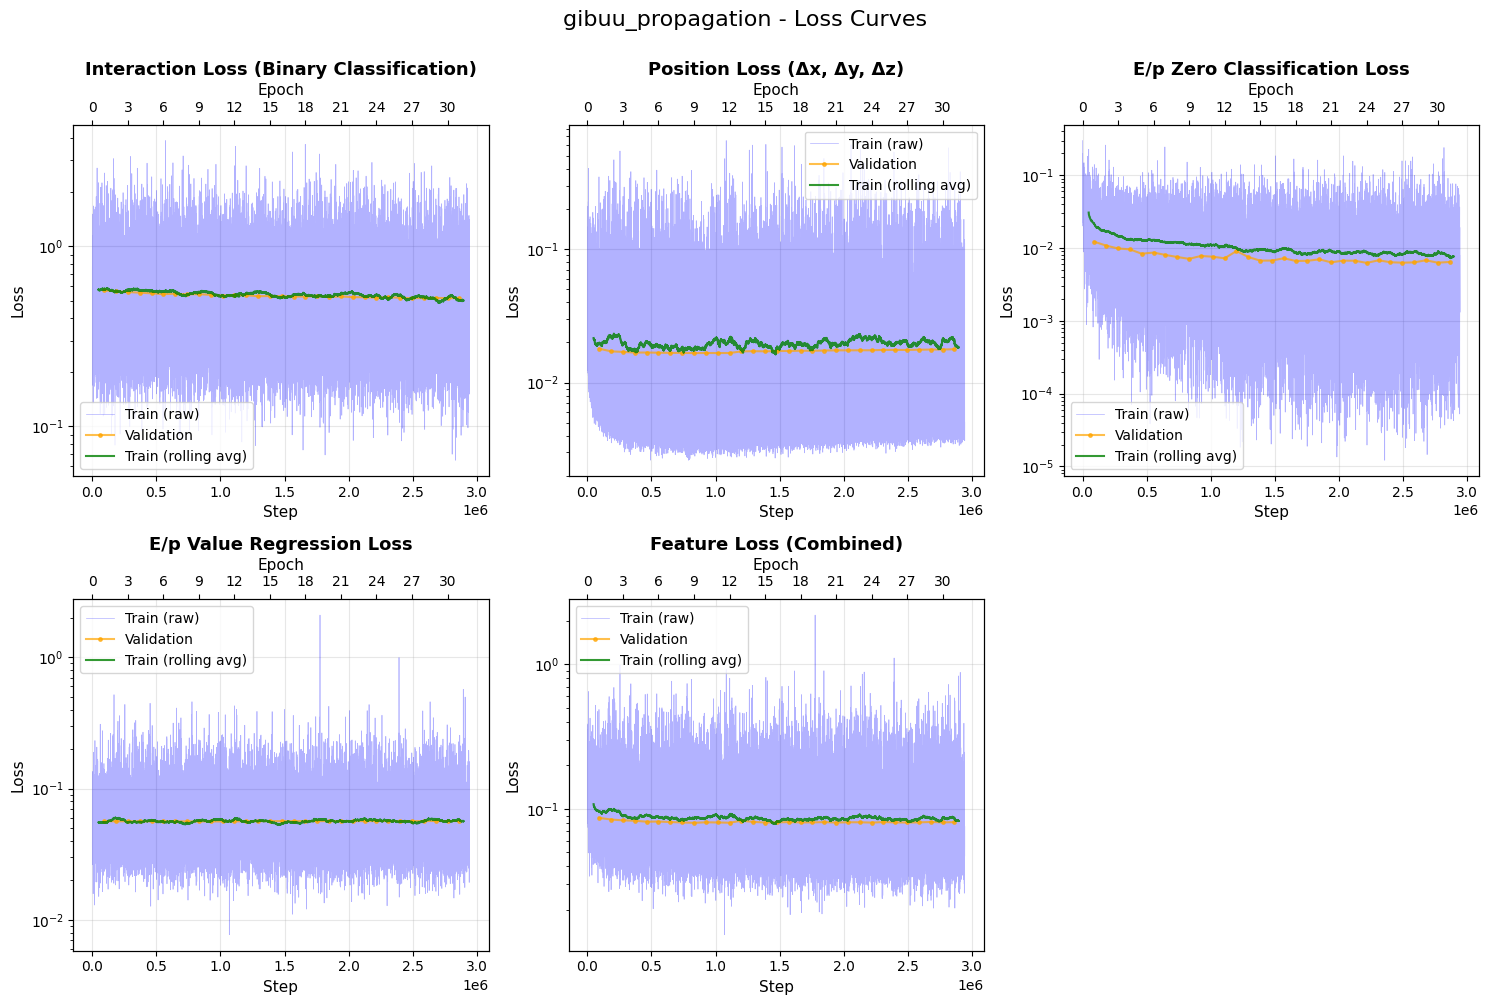

In [15]:
### Plot Loss Curves
from gibuu_transformer import plot_loss_curves
import matplotlib.pyplot as plt
import pandas as pd

EXPERIMENT_NAME = "gibuu_propagation"
COMBINE_CSV = True
if COMBINE_CSV:
    csv_idx_list = [1, 2] # modify the list
    csv_path = f"lightning_logs/{EXPERIMENT_NAME}/combined.csv"
    dfs = [pd.read_csv(f'lightning_logs/{EXPERIMENT_NAME}/version_{i}/metrics.csv') for i in csv_idx_list]
    combined = pd.concat(dfs, ignore_index=True)
    combined.to_csv(csv_path, index=False)
else:
    csv_idx = 0 # modify the index
    csv_path = f"lightning_logs/{EXPERIMENT_NAME}/version_{csv_idx}/metrics.csv"

# Option 2: Plot from combined CSV (if you've combined multiple versions)
# csv_path = f"lightning_logs/{EXPERIMENT_NAME}/combined.csv"

fig, axes = plot_loss_curves(
    csv_path=csv_path,
    mode='propagation',
    figsize=(15, 10),
    title=f'{EXPERIMENT_NAME} - Loss Curves',
    logy=True,
    custom_epoch_ticks = 10
)

if fig is not None:
    plt.show()

---

## Test

Load trained model and test predictions.


### Load Trained Model


In [ ]:
# Load best checkpoint
checkpoint_path = trainer.checkpoint_callback.best_model_path
# Or specify manually:
# checkpoint_path = "lightning_logs/gibuu_propagation/checkpoints/last.ckpt"

model_loaded = GiBUUPropagationLightning.load_from_checkpoint(checkpoint_path)
model_loaded.eval()
model_loaded.to('cuda' if torch.cuda.is_available() else 'cpu')

print(f"✓ Model loaded from: {checkpoint_path}")


### Test Predictions


In [ ]:
# Get a test batch
test_batch = next(iter(val_loader))

# Move to device
device = next(model_loaded.parameters()).device
test_batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in test_batch.items()}

# Predict
with torch.no_grad():
    output = model_loaded(
        test_batch['particle_types'],
        test_batch['input_features'],
        test_batch['padding_mask']
    )

print("✓ Predictions made!")
print(f"\nOutput keys: {output.keys()}")
if 'predicted_deltas' in output:
    print(f"  Predicted deltas shape: {output['predicted_deltas'].shape}")
print(f"  Interaction prediction shape: {output['interaction_prediction'].shape}")
print(f"\nInteraction predictions (first 10): {output['interaction_prediction'][:10].cpu().numpy()}")
print(f"True interactions (first 10): {test_batch['target_interaction'][:10].cpu().numpy()}")


### Evaluate Accuracy


In [ ]:
# Evaluate on validation set
model_loaded.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
        output = model_loaded(
            batch['particle_types'],
            batch['input_features'],
            batch['padding_mask']
        )
        
        # Interaction predictions (binary)
        preds = (output['interaction_prediction'] > 0.5).long()
        all_preds.append(preds.cpu())
        all_targets.append(batch['target_interaction'].cpu())

all_preds = torch.cat(all_preds)
all_targets = torch.cat(all_targets)

# Calculate metrics
accuracy = (all_preds == all_targets).float().mean()
true_positives = ((all_preds == 1) & (all_targets == 1)).sum()
false_positives = ((all_preds == 1) & (all_targets == 0)).sum()
false_negatives = ((all_preds == 0) & (all_targets == 1)).sum()
true_negatives = ((all_preds == 0) & (all_targets == 0)).sum()

precision = true_positives / (true_positives + false_positives + 1e-8)
recall = true_positives / (true_positives + false_negatives + 1e-8)
f1 = 2 * precision * recall / (precision + recall + 1e-8)

print("\n" + "="*60)
print("VALIDATION SET RESULTS")
print("="*60)
print(f"Interaction Prediction Accuracy: {accuracy:.4f}")
print(f"\nConfusion Matrix:")
print(f"  True Positives:  {true_positives:6d}")
print(f"  False Positives: {false_positives:6d}")
print(f"  False Negatives: {false_negatives:6d}")
print(f"  True Negatives:  {true_negatives:6d}")
print(f"\nMetrics:")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")
print("="*60)


In [ ]:
# End of notebook
